In [4]:
import sympy as sp

In [5]:
%pip install -e .

Obtaining file:///Users/rolandmitric/WORK/GITHUB/master_programming_2026/live_notebooks
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for theochem_live (pyproject.toml) ... done
  Created wheel for theochem_live: filename=theochem_live-0.1.0-0.editable-py3-none-any.whl size=2787 sha256=b94984bff0feb73dc63a2b3d2539d22c932b7012d7bb4d203d04d9a808468dab
  Stored in directory: /private/var/folders/jx/0m_kyw357_b256pffxmlcw2w0000gn/T/pip-ephem-wheel-cache-tpznesgy/wheels/59/e8/ff/5287d38cd8dacfc9a1afddc99144d20a879c5c13951b373f14
Successfully built theochem_live
  Attempting uninstall: theochem_live
    Found existing installation: theochem_live 0.1.0
    Uninstalling theochem_live-0.1.0:
      Successfully uninstalled theochem_live-0.1.0
Note: you may need to restart the kernel to use updated packages.


In [6]:
from functools import lru_cache

@lru_cache(maxsize = None)
def get_ckn(k: int, n: int, p):
    if k<0 or k>n:
        return sp.Integer(0)
    if n == 0:
        return sp.Integer(1) if k==0 else sp.Integer(0)
    return get_ckn(k-1, n-1, p)/(2*p) + (k+1)*get_ckn(k+1, n-1, p)


### Implementation of overlap integrals

In [7]:
alpha, beta = sp.symbols('alpha beta', real = True, positive = True)
Ax, Ay, Az = sp.symbols('Ax Ay Az', real = True)
Bx, By, Bz = sp.symbols('Bx By Bz', real = True)

p = alpha + beta
q = alpha*beta/p
RAB2 = (Ax-Bx)**2 + (Ay-By)**2 + (Az-Bz)**2


In [8]:
S00 = (sp.sqrt(sp.pi/p))**3 * sp.exp(-q*RAB2)
S00

pi**(3/2)*exp(-alpha*beta*((Ax - Bx)**2 + (Ay - By)**2 + (Az - Bz)**2)/(alpha + beta))/(alpha + beta)**(3/2)

In [9]:
def build_derivative_table(base_integral, Lmax, Avars, Bvars, indices):
    Ax, Ay, Az = Avars
    Bx, By, Bz = Bvars
    
    @lru_cache(maxsize=None)
    def derivative(i,j,k,l,m,n):
        if (i,j,k,l,m,n) == (0,0,0,0,0,0):
            return base_integral
        if i>0:
            return sp.diff(derivative(i-1,j,k,l,m,n),Ax)
        if j>0:
            return sp.diff(derivative(i,j-1,k,l,m,n),Ay)
        if k>0:
            return sp.diff(derivative(i,j,k-1,l,m,n),Az) 
        if l>0:
            return sp.diff(derivative(i,j,k,l-1,m,n),Bx)
        if m>0:
            return sp.diff(derivative(i,j,k,l,m-1,n),By)
        return sp.diff(derivative(i,j,k,l,m,n-1),Bz) 
    
    derivatives_dict = {}
    for (i,j,k,l,m,n) in indices:
        derivatives_dict[(i,j,k,l,m,n)] = derivative(i,j,k,l,m,n).simplify()
    return derivatives_dict

## Generate all induces up to Lmax

In [10]:
Lmax = 2

In [31]:
from src_live import l_to_ijk
integral_indices=[]
ijk = [t for L in range(Lmax+1) for t in l_to_ijk(L)]
for i in ijk:
    for j in ijk:
        integral_indices.append(i+j)
integral_indices

[(0, 0, 0, 0, 0, 0),
 (0, 0, 0, 1, 0, 0),
 (0, 0, 0, 0, 1, 0),
 (0, 0, 0, 0, 0, 1),
 (0, 0, 0, 2, 0, 0),
 (0, 0, 0, 1, 1, 0),
 (0, 0, 0, 1, 0, 1),
 (0, 0, 0, 0, 2, 0),
 (0, 0, 0, 0, 1, 1),
 (0, 0, 0, 0, 0, 2),
 (1, 0, 0, 0, 0, 0),
 (1, 0, 0, 1, 0, 0),
 (1, 0, 0, 0, 1, 0),
 (1, 0, 0, 0, 0, 1),
 (1, 0, 0, 2, 0, 0),
 (1, 0, 0, 1, 1, 0),
 (1, 0, 0, 1, 0, 1),
 (1, 0, 0, 0, 2, 0),
 (1, 0, 0, 0, 1, 1),
 (1, 0, 0, 0, 0, 2),
 (0, 1, 0, 0, 0, 0),
 (0, 1, 0, 1, 0, 0),
 (0, 1, 0, 0, 1, 0),
 (0, 1, 0, 0, 0, 1),
 (0, 1, 0, 2, 0, 0),
 (0, 1, 0, 1, 1, 0),
 (0, 1, 0, 1, 0, 1),
 (0, 1, 0, 0, 2, 0),
 (0, 1, 0, 0, 1, 1),
 (0, 1, 0, 0, 0, 2),
 (0, 0, 1, 0, 0, 0),
 (0, 0, 1, 1, 0, 0),
 (0, 0, 1, 0, 1, 0),
 (0, 0, 1, 0, 0, 1),
 (0, 0, 1, 2, 0, 0),
 (0, 0, 1, 1, 1, 0),
 (0, 0, 1, 1, 0, 1),
 (0, 0, 1, 0, 2, 0),
 (0, 0, 1, 0, 1, 1),
 (0, 0, 1, 0, 0, 2),
 (2, 0, 0, 0, 0, 0),
 (2, 0, 0, 1, 0, 0),
 (2, 0, 0, 0, 1, 0),
 (2, 0, 0, 0, 0, 1),
 (2, 0, 0, 2, 0, 0),
 (2, 0, 0, 1, 1, 0),
 (2, 0, 0, 1, 0, 1),
 (2, 0, 0, 0,

In [32]:
derivatives_dict = build_derivative_table(S00, Lmax, (Ax,Ay,Az), (Bx,By,Bz), integral_indices)

## Generate only canonical indices

In [33]:
from itertools import permutations

S3 = list(permutations((0,1,2)))

def permute(ijk, permutation):
    return tuple(ijk[i] for i in permutation)

def get_canonical_indices(La, Lb):
    canonical_indices = set()
    for (i,j,k) in l_to_ijk(La):
        for (l,m,n) in l_to_ijk(Lb):
            orbit_ijklmn = set()
            for permutation in S3:
                permuted_ijk = permute((i,j,k), permutation)
                permuted_lmn = permute((l,m,n), permutation)
                idx = permuted_ijk + permuted_lmn
                orbit_ijklmn.add(idx)
                idx = permuted_lmn + permuted_ijk
                orbit_ijklmn.add(idx)
            canonical_indices.add(min(orbit_ijklmn))
    return canonical_indices
                
indices = set()
for La in range(Lmax+1):
    for Lb in range(Lmax+1):
        indices.update(get_canonical_indices(La, Lb))   
indices = sorted(indices)
canonical_to_rep = {idx: num for num, idx in enumerate(indices)}
canonical_to_rep

{(0, 0, 0, 0, 0, 0): 0,
 (0, 0, 0, 0, 0, 1): 1,
 (0, 0, 0, 0, 0, 2): 2,
 (0, 0, 0, 0, 1, 1): 3,
 (0, 0, 1, 0, 0, 1): 4,
 (0, 0, 1, 0, 0, 2): 5,
 (0, 0, 1, 0, 1, 0): 6,
 (0, 0, 1, 0, 1, 1): 7,
 (0, 0, 1, 0, 2, 0): 8,
 (0, 0, 1, 1, 1, 0): 9,
 (0, 0, 2, 0, 0, 2): 10,
 (0, 0, 2, 0, 1, 1): 11,
 (0, 0, 2, 0, 2, 0): 12,
 (0, 0, 2, 1, 1, 0): 13,
 (0, 1, 1, 0, 1, 1): 14,
 (0, 1, 1, 1, 0, 1): 15}

### Generate permutation mappings
For each set of indices generate a permutation that maps the given set to a canonical index.
Construct the dictionary with key = ijklmn and values = (permutation, swap)

In [34]:
ijklmn_to_rep = {}

for La in range(Lmax+1):
    for Lb in range(Lmax+1):
        ijk_list = l_to_ijk(La)
        lmn_list = l_to_ijk(Lb)
        for ijk in ijk_list:
            for lmn in lmn_list:
                ijklmn = ijk + lmn
                for canonical in indices:
                    for perm in S3:
                        pijk = permute(ijk, perm)
                        plmn = permute(lmn, perm)
                        pijklmn = pijk + plmn
                        if pijklmn == canonical:
                            ijklmn_to_rep[ijklmn] = (canonical_to_rep[canonical],perm, False)
                        plmnijk = plmn + pijk
                        if plmnijk == canonical:
                            ijklmn_to_rep[ijklmn] = (canonical_to_rep[canonical],perm, True)



In [35]:
from pprint import pformat

print(f"IJKLMN_TO_REP = {pformat(ijklmn_to_rep, sort_dicts=False)}")

IJKLMN_TO_REP = {(0, 0, 0, 0, 0, 0): (0, (2, 1, 0), True),
 (0, 0, 0, 1, 0, 0): (1, (2, 1, 0), False),
 (0, 0, 0, 0, 1, 0): (1, (2, 0, 1), False),
 (0, 0, 0, 0, 0, 1): (1, (1, 0, 2), False),
 (0, 0, 0, 2, 0, 0): (2, (2, 1, 0), False),
 (0, 0, 0, 1, 1, 0): (3, (2, 1, 0), False),
 (0, 0, 0, 1, 0, 1): (3, (1, 2, 0), False),
 (0, 0, 0, 0, 2, 0): (2, (2, 0, 1), False),
 (0, 0, 0, 0, 1, 1): (3, (0, 2, 1), False),
 (0, 0, 0, 0, 0, 2): (2, (1, 0, 2), False),
 (1, 0, 0, 0, 0, 0): (1, (2, 1, 0), True),
 (0, 1, 0, 0, 0, 0): (1, (2, 0, 1), True),
 (0, 0, 1, 0, 0, 0): (1, (1, 0, 2), True),
 (1, 0, 0, 1, 0, 0): (4, (2, 1, 0), True),
 (1, 0, 0, 0, 1, 0): (6, (2, 1, 0), False),
 (1, 0, 0, 0, 0, 1): (6, (1, 2, 0), False),
 (0, 1, 0, 1, 0, 0): (6, (2, 1, 0), True),
 (0, 1, 0, 0, 1, 0): (4, (2, 0, 1), True),
 (0, 1, 0, 0, 0, 1): (6, (0, 2, 1), False),
 (0, 0, 1, 1, 0, 0): (6, (1, 2, 0), True),
 (0, 0, 1, 0, 1, 0): (6, (0, 2, 1), True),
 (0, 0, 1, 0, 0, 1): (4, (1, 0, 2), True),
 (1, 0, 0, 2, 0, 0): (5, (

In [51]:
LA_LB_TO_IJKLMN = {}
for la in range(Lmax + 1):
    for lb in range(Lmax + 1):
        LA_LB_TO_IJKLMN[(la, lb)] = [
            ijk + lmn
            for ijk in l_to_ijk(la)
            for lmn in l_to_ijk(lb)
        ]

print(f"LA_LB_TO_IJKLMN = {pformat(LA_LB_TO_IJKLMN, sort_dicts=False)}")

LA_LB_TO_IJKLMN = {(0, 0): [(0, 0, 0, 0, 0, 0)],
 (0, 1): [(0, 0, 0, 1, 0, 0), (0, 0, 0, 0, 1, 0), (0, 0, 0, 0, 0, 1)],
 (0, 2): [(0, 0, 0, 2, 0, 0),
          (0, 0, 0, 1, 1, 0),
          (0, 0, 0, 1, 0, 1),
          (0, 0, 0, 0, 2, 0),
          (0, 0, 0, 0, 1, 1),
          (0, 0, 0, 0, 0, 2)],
 (1, 0): [(1, 0, 0, 0, 0, 0), (0, 1, 0, 0, 0, 0), (0, 0, 1, 0, 0, 0)],
 (1, 1): [(1, 0, 0, 1, 0, 0),
          (1, 0, 0, 0, 1, 0),
          (1, 0, 0, 0, 0, 1),
          (0, 1, 0, 1, 0, 0),
          (0, 1, 0, 0, 1, 0),
          (0, 1, 0, 0, 0, 1),
          (0, 0, 1, 1, 0, 0),
          (0, 0, 1, 0, 1, 0),
          (0, 0, 1, 0, 0, 1)],
 (1, 2): [(1, 0, 0, 2, 0, 0),
          (1, 0, 0, 1, 1, 0),
          (1, 0, 0, 1, 0, 1),
          (1, 0, 0, 0, 2, 0),
          (1, 0, 0, 0, 1, 1),
          (1, 0, 0, 0, 0, 2),
          (0, 1, 0, 2, 0, 0),
          (0, 1, 0, 1, 1, 0),
          (0, 1, 0, 1, 0, 1),
          (0, 1, 0, 0, 2, 0),
          (0, 1, 0, 0, 1, 1),
          (0, 1, 0, 0, 0, 2

In [37]:
def get_integral_expressions(integral_indices, derivatives_dict, alpha, beta):
    integral_expressions = {}

    for (i,j,k,l,m,n) in integral_indices:

        ci = [get_ckn(o, i, alpha) for o in range(i + 1)]
        cj = [get_ckn(p, j, alpha) for p in range(j + 1)]
        ck = [get_ckn(q, k, alpha) for q in range(k + 1)]

        cl = [get_ckn(r, l, beta) for r in range(l + 1)]
        cm = [get_ckn(s, m, beta) for s in range(m + 1)]
        cn = [get_ckn(t, n, beta) for t in range(n + 1)]

        expr = 0
        for o, co in enumerate(ci):
            for p, cp in enumerate(cj):
                for q, cq in enumerate(ck):
                    for r, cr in enumerate(cl):
                        for s, cs in enumerate(cm):
                            for t, ct in enumerate(cn):
                                expr += (
                                    co * cp * cq * cr * cs * ct
                                    * derivatives_dict[(o, p, q, r, s, t)]
                                )

        integral_expressions[(i,j,k,l,m,n)] = sp.simplify(expr)
    return integral_expressions

In [38]:
integral_expressions = get_integral_expressions(indices, derivatives_dict, alpha, beta)

In [39]:
Dx, Dy, Dz, D2, P, Q = sp.symbols(
    'Dx Dy Dz D2 P Q',
    real=True,
)

subsdict = {
    Ax - Bx: Dx,
    Ay - By: Dy,
    Az - Bz: Dz,
    (Ax - Bx)**2 + (Ay - By)**2 + (Az - Bz)**2: RAB2,
    alpha + beta: P,
    alpha * beta: Q,
}
for key, value in integral_expressions.items():
    integral_expressions[key] = value.subs(subsdict)
    print(key, integral_expressions[key])

(0, 0, 0, 0, 0, 0) pi**(3/2)*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/P**(3/2)
(0, 0, 0, 0, 0, 1) pi**(3/2)*Dz*alpha*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/P**(5/2)
(0, 0, 0, 0, 0, 2) pi**(3/2)*(P**2 - alpha*(-2*Dz**2*Q + P))*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/(2*P**(7/2)*beta)
(0, 0, 0, 0, 1, 1) pi**(3/2)*Dy*Dz*alpha**2*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/P**(7/2)
(0, 0, 1, 0, 0, 1) pi**(3/2)*(-2*Dz**2*Q + P)*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/(2*P**(7/2))
(0, 0, 1, 0, 0, 2) pi**(3/2)*(-Dz*P**2 + Dz*alpha*(-2*Dz**2*Q + 3*alpha + 3*beta))*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/(2*P**(9/2))
(0, 0, 1, 0, 1, 0) -pi**(3/2)*Dy*Dz*Q*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/P**(7/2)
(0, 0, 1, 0, 1, 1) pi**(3/2)*Dy*alpha*(-2*Dz**2*Q + P)*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/(2*P**(9/2))
(0, 0, 1, 0, 2, 0) pi**(3/2)*(-Dz*P**2 - Dz*alpha*(2*Dy**2*Q - P))*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/(2*P**(9/2))
(0, 0, 1, 1, 1, 0) -pi**(3/2)*Dx*Dy*Dz*Q*alpha*exp(-Q*(Dx**2 + Dy**2 + Dz**2)/P)/P**(9/2)
(0, 0, 2, 0, 0, 2) pi**(3/2)*(P**4 - 

In [40]:
from sympy.printing.numpy import NumPyPrinter, _known_constants_numpy, _known_functions_numpy

printer = NumPyPrinter()
printer._module = "np"
printer.known_functions = { k:f"np.{v}" for k,v in _known_functions_numpy.items()}
printer.known_constants = {k: f"np.{v}" for k, v in _known_constants_numpy.items()}


In [41]:
def write_onel_module(path, name = "S", variables = None,  integral_expressions = None):
    lines = ["import numpy as np\n",
             "from numba import njit\n",
             "@njit(cache=True, fastmath=True)\n",
              f"def {name}({variables}):\n"]
    
    for rep, value in enumerate(integral_expressions.values()):
        lines.append(f"    if rep == {rep}:\n")
        lines.append(f"        return {printer.doprint(value)}\n")
    lines.append("    raise ValueError(\"Invalid overlap representative\")\n")
    path = path / (name + ".py")
    with open(path, "w", encoding="utf-8") as f:
        f.write("".join(lines))

In [42]:
from pathlib import Path
path = Path.cwd() / "src_live"
write_onel_module(path, name = "S", variables = "rep, Dx, Dy, Dz, P, Q, RAB2, alpha, beta", integral_expressions = integral_expressions)

In [43]:
import timeit
import importlib
from src_live import S
importlib.reload(S)
%timeit S.S(15, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0,1.0)


The slowest run took 9.42 times longer than the fastest. This could mean that an intermediate result is being cached.
512 ns ± 599 ns per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Overlap shell pair

In [52]:
IJKLMN_TO_REP = {(0, 0, 0, 0, 0, 0): (0, (2, 1, 0), True),
 (0, 0, 0, 0, 0, 1): (1, (1, 0, 2), False),
 (0, 0, 0, 0, 1, 0): (1, (2, 0, 1), False),
 (0, 0, 0, 1, 0, 0): (1, (2, 1, 0), False),
 (0, 0, 0, 0, 0, 2): (2, (1, 0, 2), False),
 (0, 0, 0, 0, 1, 1): (3, (0, 2, 1), False),
 (0, 0, 0, 0, 2, 0): (2, (2, 0, 1), False),
 (0, 0, 0, 1, 0, 1): (3, (1, 2, 0), False),
 (0, 0, 0, 1, 1, 0): (3, (2, 1, 0), False),
 (0, 0, 0, 2, 0, 0): (2, (2, 1, 0), False),
 (0, 0, 1, 0, 0, 0): (1, (1, 0, 2), True),
 (0, 1, 0, 0, 0, 0): (1, (2, 0, 1), True),
 (1, 0, 0, 0, 0, 0): (1, (2, 1, 0), True),
 (0, 0, 1, 0, 0, 1): (4, (1, 0, 2), True),
 (0, 0, 1, 0, 1, 0): (6, (0, 2, 1), True),
 (0, 0, 1, 1, 0, 0): (6, (1, 2, 0), True),
 (0, 1, 0, 0, 0, 1): (6, (0, 2, 1), False),
 (0, 1, 0, 0, 1, 0): (4, (2, 0, 1), True),
 (0, 1, 0, 1, 0, 0): (6, (2, 1, 0), True),
 (1, 0, 0, 0, 0, 1): (6, (1, 2, 0), False),
 (1, 0, 0, 0, 1, 0): (6, (2, 1, 0), False),
 (1, 0, 0, 1, 0, 0): (4, (2, 1, 0), True),
 (0, 0, 1, 0, 0, 2): (5, (1, 0, 2), False),
 (0, 0, 1, 0, 1, 1): (7, (0, 1, 2), False),
 (0, 0, 1, 0, 2, 0): (8, (0, 1, 2), False),
 (0, 0, 1, 1, 0, 1): (7, (1, 0, 2), False),
 (0, 0, 1, 1, 1, 0): (9, (1, 0, 2), False),
 (0, 0, 1, 2, 0, 0): (8, (1, 0, 2), False),
 (0, 1, 0, 0, 0, 2): (8, (0, 2, 1), False),
 (0, 1, 0, 0, 1, 1): (7, (0, 2, 1), False),
 (0, 1, 0, 0, 2, 0): (5, (2, 0, 1), False),
 (0, 1, 0, 1, 0, 1): (9, (2, 0, 1), False),
 (0, 1, 0, 1, 1, 0): (7, (2, 0, 1), False),
 (0, 1, 0, 2, 0, 0): (8, (2, 0, 1), False),
 (1, 0, 0, 0, 0, 2): (8, (1, 2, 0), False),
 (1, 0, 0, 0, 1, 1): (9, (2, 1, 0), False),
 (1, 0, 0, 0, 2, 0): (8, (2, 1, 0), False),
 (1, 0, 0, 1, 0, 1): (7, (1, 2, 0), False),
 (1, 0, 0, 1, 1, 0): (7, (2, 1, 0), False),
 (1, 0, 0, 2, 0, 0): (5, (2, 1, 0), False),
 (0, 0, 2, 0, 0, 0): (2, (1, 0, 2), True),
 (0, 1, 1, 0, 0, 0): (3, (0, 2, 1), True),
 (0, 2, 0, 0, 0, 0): (2, (2, 0, 1), True),
 (1, 0, 1, 0, 0, 0): (3, (1, 2, 0), True),
 (1, 1, 0, 0, 0, 0): (3, (2, 1, 0), True),
 (2, 0, 0, 0, 0, 0): (2, (2, 1, 0), True),
 (0, 0, 2, 0, 0, 1): (5, (1, 0, 2), True),
 (0, 0, 2, 0, 1, 0): (8, (0, 2, 1), True),
 (0, 0, 2, 1, 0, 0): (8, (1, 2, 0), True),
 (0, 1, 1, 0, 0, 1): (7, (0, 1, 2), True),
 (0, 1, 1, 0, 1, 0): (7, (0, 2, 1), True),
 (0, 1, 1, 1, 0, 0): (9, (2, 1, 0), True),
 (0, 2, 0, 0, 0, 1): (8, (0, 1, 2), True),
 (0, 2, 0, 0, 1, 0): (5, (2, 0, 1), True),
 (0, 2, 0, 1, 0, 0): (8, (2, 1, 0), True),
 (1, 0, 1, 0, 0, 1): (7, (1, 0, 2), True),
 (1, 0, 1, 0, 1, 0): (9, (2, 0, 1), True),
 (1, 0, 1, 1, 0, 0): (7, (1, 2, 0), True),
 (1, 1, 0, 0, 0, 1): (9, (1, 0, 2), True),
 (1, 1, 0, 0, 1, 0): (7, (2, 0, 1), True),
 (1, 1, 0, 1, 0, 0): (7, (2, 1, 0), True),
 (2, 0, 0, 0, 0, 1): (8, (1, 0, 2), True),
 (2, 0, 0, 0, 1, 0): (8, (2, 0, 1), True),
 (2, 0, 0, 1, 0, 0): (5, (2, 1, 0), True),
 (0, 0, 2, 0, 0, 2): (10, (1, 0, 2), True),
 (0, 0, 2, 0, 1, 1): (11, (0, 1, 2), False),
 (0, 0, 2, 0, 2, 0): (12, (0, 2, 1), True),
 (0, 0, 2, 1, 0, 1): (11, (1, 0, 2), False),
 (0, 0, 2, 1, 1, 0): (13, (1, 0, 2), False),
 (0, 0, 2, 2, 0, 0): (12, (1, 2, 0), True),
 (0, 1, 1, 0, 0, 2): (11, (0, 1, 2), True),
 (0, 1, 1, 0, 1, 1): (14, (0, 2, 1), True),
 (0, 1, 1, 0, 2, 0): (11, (0, 2, 1), True),
 (0, 1, 1, 1, 0, 1): (15, (1, 0, 2), True),
 (0, 1, 1, 1, 1, 0): (15, (2, 0, 1), True),
 (0, 1, 1, 2, 0, 0): (13, (2, 1, 0), True),
 (0, 2, 0, 0, 0, 2): (12, (0, 2, 1), False),
 (0, 2, 0, 0, 1, 1): (11, (0, 2, 1), False),
 (0, 2, 0, 0, 2, 0): (10, (2, 0, 1), True),
 (0, 2, 0, 1, 0, 1): (13, (2, 0, 1), False),
 (0, 2, 0, 1, 1, 0): (11, (2, 0, 1), False),
 (0, 2, 0, 2, 0, 0): (12, (2, 1, 0), True),
 (1, 0, 1, 0, 0, 2): (11, (1, 0, 2), True),
 (1, 0, 1, 0, 1, 1): (15, (1, 0, 2), False),
 (1, 0, 1, 0, 2, 0): (13, (2, 0, 1), True),
 (1, 0, 1, 1, 0, 1): (14, (1, 2, 0), True),
 (1, 0, 1, 1, 1, 0): (15, (2, 1, 0), True),
 (1, 0, 1, 2, 0, 0): (11, (1, 2, 0), True),
 (1, 1, 0, 0, 0, 2): (13, (1, 0, 2), True),
 (1, 1, 0, 0, 1, 1): (15, (2, 0, 1), False),
 (1, 1, 0, 0, 2, 0): (11, (2, 0, 1), True),
 (1, 1, 0, 1, 0, 1): (15, (2, 1, 0), False),
 (1, 1, 0, 1, 1, 0): (14, (2, 1, 0), True),
 (1, 1, 0, 2, 0, 0): (11, (2, 1, 0), True),
 (2, 0, 0, 0, 0, 2): (12, (1, 2, 0), False),
 (2, 0, 0, 0, 1, 1): (13, (2, 1, 0), False),
 (2, 0, 0, 0, 2, 0): (12, (2, 1, 0), False),
 (2, 0, 0, 1, 0, 1): (11, (1, 2, 0), False),
 (2, 0, 0, 1, 1, 0): (11, (2, 1, 0), False),
 (2, 0, 0, 2, 0, 0): (10, (2, 1, 0), True)}

LA_LB_TO_IJKLMN = {(0, 0): [(0, 0, 0, 0, 0, 0)],
 (0, 1): [(0, 0, 0, 1, 0, 0), (0, 0, 0, 0, 1, 0), (0, 0, 0, 0, 0, 1)],
 (0, 2): [(0, 0, 0, 2, 0, 0),
          (0, 0, 0, 1, 1, 0),
          (0, 0, 0, 1, 0, 1),
          (0, 0, 0, 0, 2, 0),
          (0, 0, 0, 0, 1, 1),
          (0, 0, 0, 0, 0, 2)],
 (1, 0): [(1, 0, 0, 0, 0, 0), (0, 1, 0, 0, 0, 0), (0, 0, 1, 0, 0, 0)],
 (1, 1): [(1, 0, 0, 1, 0, 0),
          (1, 0, 0, 0, 1, 0),
          (1, 0, 0, 0, 0, 1),
          (0, 1, 0, 1, 0, 0),
          (0, 1, 0, 0, 1, 0),
          (0, 1, 0, 0, 0, 1),
          (0, 0, 1, 1, 0, 0),
          (0, 0, 1, 0, 1, 0),
          (0, 0, 1, 0, 0, 1)],
 (1, 2): [(1, 0, 0, 2, 0, 0),
          (1, 0, 0, 1, 1, 0),
          (1, 0, 0, 1, 0, 1),
          (1, 0, 0, 0, 2, 0),
          (1, 0, 0, 0, 1, 1),
          (1, 0, 0, 0, 0, 2),
          (0, 1, 0, 2, 0, 0),
          (0, 1, 0, 1, 1, 0),
          (0, 1, 0, 1, 0, 1),
          (0, 1, 0, 0, 2, 0),
          (0, 1, 0, 0, 1, 1),
          (0, 1, 0, 0, 0, 2),
          (0, 0, 1, 2, 0, 0),
          (0, 0, 1, 1, 1, 0),
          (0, 0, 1, 1, 0, 1),
          (0, 0, 1, 0, 2, 0),
          (0, 0, 1, 0, 1, 1),
          (0, 0, 1, 0, 0, 2)],
 (2, 0): [(2, 0, 0, 0, 0, 0),
          (1, 1, 0, 0, 0, 0),
          (1, 0, 1, 0, 0, 0),
          (0, 2, 0, 0, 0, 0),
          (0, 1, 1, 0, 0, 0),
          (0, 0, 2, 0, 0, 0)],
 (2, 1): [(2, 0, 0, 1, 0, 0),
          (2, 0, 0, 0, 1, 0),
          (2, 0, 0, 0, 0, 1),
          (1, 1, 0, 1, 0, 0),
          (1, 1, 0, 0, 1, 0),
          (1, 1, 0, 0, 0, 1),
          (1, 0, 1, 1, 0, 0),
          (1, 0, 1, 0, 1, 0),
          (1, 0, 1, 0, 0, 1),
          (0, 2, 0, 1, 0, 0),
          (0, 2, 0, 0, 1, 0),
          (0, 2, 0, 0, 0, 1),
          (0, 1, 1, 1, 0, 0),
          (0, 1, 1, 0, 1, 0),
          (0, 1, 1, 0, 0, 1),
          (0, 0, 2, 1, 0, 0),
          (0, 0, 2, 0, 1, 0),
          (0, 0, 2, 0, 0, 1)],
 (2, 2): [(2, 0, 0, 2, 0, 0),
          (2, 0, 0, 1, 1, 0),
          (2, 0, 0, 1, 0, 1),
          (2, 0, 0, 0, 2, 0),
          (2, 0, 0, 0, 1, 1),
          (2, 0, 0, 0, 0, 2),
          (1, 1, 0, 2, 0, 0),
          (1, 1, 0, 1, 1, 0),
          (1, 1, 0, 1, 0, 1),
          (1, 1, 0, 0, 2, 0),
          (1, 1, 0, 0, 1, 1),
          (1, 1, 0, 0, 0, 2),
          (1, 0, 1, 2, 0, 0),
          (1, 0, 1, 1, 1, 0),
          (1, 0, 1, 1, 0, 1),
          (1, 0, 1, 0, 2, 0),
          (1, 0, 1, 0, 1, 1),
          (1, 0, 1, 0, 0, 2),
          (0, 2, 0, 2, 0, 0),
          (0, 2, 0, 1, 1, 0),
          (0, 2, 0, 1, 0, 1),
          (0, 2, 0, 0, 2, 0),
          (0, 2, 0, 0, 1, 1),
          (0, 2, 0, 0, 0, 2),
          (0, 1, 1, 2, 0, 0),
          (0, 1, 1, 1, 1, 0),
          (0, 1, 1, 1, 0, 1),
          (0, 1, 1, 0, 2, 0),
          (0, 1, 1, 0, 1, 1),
          (0, 1, 1, 0, 0, 2),
          (0, 0, 2, 2, 0, 0),
          (0, 0, 2, 1, 1, 0),
          (0, 0, 2, 1, 0, 1),
          (0, 0, 2, 0, 2, 0),
          (0, 0, 2, 0, 1, 1),
          (0, 0, 2, 0, 0, 2)]}

S_fn = S.S
LA_LB_TO_IJKLMN = {key: np.ascontiguousarray(value, dtype=np.int64) for key, value in LA_LB_TO_IJKLMN.items()}
LOOKUP_SHAPE = tuple(max(key[pos] for key in IJKLMN_TO_REP) + 1 for pos in range(6))
IJKLMN_REP = np.empty(LOOKUP_SHAPE, dtype=np.int64)
IJKLMN_PERM = np.empty(LOOKUP_SHAPE + (3,), dtype=np.int64)
IJKLMN_SWAP = np.zeros(LOOKUP_SHAPE, dtype=np.int64)
for key, (rep, perm, swap) in IJKLMN_TO_REP.items():
    IJKLMN_REP[key] = rep
    IJKLMN_PERM[key] = perm
    IJKLMN_SWAP[key] = 1 if swap else 0

In [ ]:

@njit(fastmath=True)
def overlap_shell_pair(exp_a, coeff_a, norm_a, center_a,
                       exp_b, coeff_b, norm_b, center_b,
                       ijklmn):
    dim_a = norm_a.shape[1]
    dim_b = norm_b.shape[1]
    out = np.zeros((dim_a, dim_b), dtype=np.float64)
    RAB2 = (center_a[0] - center_b[0])**2 + (center_a[1] - center_b[1])**2 + (center_a[2] - center_b[2])**2

    for idx in range(ijklmn.shape[0]):
        ia = idx // dim_b
        ib = idx % dim_b
        i, j, k, l, m, n = ijklmn[idx]
        rep = IJKLMN_REP[i, j, k, l, m, n]
        perm0 = IJKLMN_PERM[i, j, k, l, m, n, 0]
        perm1 = IJKLMN_PERM[i, j, k, l, m, n, 1]
        perm2 = IJKLMN_PERM[i, j, k, l, m, n, 2]
        swap = IJKLMN_SWAP[i, j, k, l, m, n]
        if swap == 0:
            Dx = center_a[perm0] - center_b[perm0]
            Dy = center_a[perm1] - center_b[perm1]
            Dz = center_a[perm2] - center_b[perm2]
        else:
            Dx = center_b[perm0] - center_a[perm0]
            Dy = center_b[perm1] - center_a[perm1]
            Dz = center_b[perm2] - center_a[perm2]
        val = 0.0
        for pa in range(exp_a.shape[0]):
            alpha_a = exp_a[pa]
            ca = coeff_a[pa] * norm_a[pa, ia]
            for pb in range(exp_b.shape[0]):
                alpha_b = exp_b[pb]
                cb = coeff_b[pb] * norm_b[pb, ib]
                P = alpha_a + alpha_b
                Q = alpha_a * alpha_b
                if swap == 0:
                    alpha = alpha_a
                    beta = alpha_b
                else:
                    alpha = alpha_b
                    beta = alpha_a
                val += ca * cb * S_fn(rep, Dx, Dy, Dz, P, Q, RAB2, alpha, beta)

        out[ia, ib] = val
    return out
    

## Molecular test data

In [54]:
from src_live import Molecule, BasisSet
benzene_xyz = """12
Benzene molecule
C 0.000000 1.402720 0.000000
C 1.214790 0.701360 0.000000
C 1.214790 -0.701360 0.000000
C 0.000000 -1.402720 0.000000
C -1.214790 -0.701360 0.000000
C -1.214790 0.701360 0.000000
H 0.000000 2.490290 0.000000
H 2.156660 1.245150 0.000000
H 2.156660 -1.245150 0.000000
H 0.000000 -2.490290 0.000000
H -2.156660 -1.245150 0.000000
H -2.156660 1.245150 0.000000
"""
benzene = Molecule.from_string(benzene_xyz)
print(benzene.to_string())
sto3g = BasisSet("sto-3g")
sto3g.download_from_bse(["H", "C", "O", "N", "B"])
print(sto3g)

12
Generated by Molecule Class
C 0.000000 1.402720 0.000000
C 1.214790 0.701360 0.000000
C 1.214790 -0.701360 0.000000
C 0.000000 -1.402720 0.000000
C -1.214790 -0.701360 0.000000
C -1.214790 0.701360 0.000000
H 0.000000 2.490290 0.000000
H 2.156660 1.245150 0.000000
H 2.156660 -1.245150 0.000000
H 0.000000 -2.490290 0.000000
H -2.156660 -1.245150 0.000000
H -2.156660 1.245150 0.000000
Dump data to sto-3g.json
Basis set: sto-3g
Element: H
l = 0, exponents = [3.42525091 0.62391373 0.1688554 ], coefficients = [0.15432897 0.53532814 0.44463454]
Element: B
l = 0, exponents = [48.79111318  8.88736217  2.40526704], coefficients = [0.15432897 0.53532814 0.44463454]
l = 0, exponents = [2.23695614 0.5198205  0.16906176], coefficients = [-0.09996723  0.39951283  0.70011547]
l = 1, exponents = [2.23695614 0.5198205  0.16906176], coefficients = [0.15591627 0.60768372 0.39195739]
Element: C
l = 0, exponents = [71.61683735 13.04509632  3.53051216], coefficients = [0.15432897 0.53532814 0.44463454]
l

## Molecule integrals class

In [ ]:
from dataclasses import dataclass, field
import copy
import numpy as np
from numba import njit
from numba.typed import List

ANG2BOHR = 1.8897261254578281

def dim_shell(l):
    return (l + 1) * (l + 2) // 2

DIM_SHELL = {l: dim_shell(l) for l in range(10)}  # Adjust the range as needed

@njit(fastmath=True)
def overlap_matrix_driver(pair_a, pair_b, offsets, exp_data, coeff_data, norm_data, center_data, ijklmn_data):
    onel_mat = np.zeros((offsets[-1], offsets[-1]), dtype=np.float64)
    for idx in range(pair_a.shape[0]):
        i = pair_a[idx]
        j = pair_b[idx]
        block = overlap_shell_pair(exp_data[i], coeff_data[i], norm_data[i], center_data[i],
                                   exp_data[j], coeff_data[j], norm_data[j], center_data[j], ijklmn_data[idx])
        a0 = offsets[i]
        a1 = offsets[i + 1]
        b0 = offsets[j]
        b1 = offsets[j + 1]
        onel_mat[a0:a1, b0:b1] = block
        if i != j:
            onel_mat[b0:b1, a0:a1] = block.T
    return onel_mat

@dataclass
class MolecularIntegrals:
    molecule: Molecule
    basis_set: BasisSet
    #stuff that we don't initialize
    shells: List[Shell] = field(default_factory=List, init=False)
    exp_data: List = field(init = False)
    coeff_data: List = field(init = False)
    norm_data: List = field(init = False)
    center_data: List = field(init = False)
    ijklmn_data: List = field(default_factory=List, init=False)

    def __post_init__(self):
        self.shells = []
        for atom in self.molecule.atoms:
            atom_basis = self.basis_set.elements[atom.symbol]
            for shell in atom_basis:
                shell_copy = copy.deepcopy(shell)
                shell_copy.set_center(np.asarray(atom.coord, dtype=np.float64) * ANG2BOHR)
                self.shells.append(shell_copy)

        self.exp_data = List()
        self.coeff_data = List()
        self.norm_data = List()
        self.center_data = List()
        for shell in self.shells:
            self.exp_data.append(np.ascontiguousarray(shell.exponents, dtype = np.float64))
            self.coeff_data.append(np.ascontiguousarray(shell.coefficients, dtype = np.float64))
            self.norm_data.append(np.ascontiguousarray(shell.norm_factors, dtype = np.float64))
            self.center_data.append(np.ascontiguousarray(shell.center, dtype = np.float64))
        
        self.dims = np.asarray([DIM_SHELL[shell.l] for shell in self.shells], dtype=np.int64)
        self.offsets = np.zeros(len(self.shells) + 1, dtype=np.int64)
        self.offsets[1:] = np.cumsum(self.dims)

        # create pair data for one electron integrals
        self.get_pair_data()

    def get_pair_data(self):
        pair_a_list = List()
        pair_b_list = List()
        for i, shell_a in enumerate(self.shells):
            for j in range(i + 1):
                shell_b = self.shells[j]
                pair_a_list.append(i)
                pair_b_list.append(j)
                ijk_lmn = LA_LB_TO_IJKLMN[(shell_a.l, shell_b.l)]
                self.ijklmn_data.append(ijk_lmn)
        self.pair_a = np.asarray(pair_a_list, dtype = np.int64) 
        self.pair_b = np.asarray(pair_b_list, dtype = np.int64)  
        
    def one_electron_driver(self, engine = overlap_shell_pair):
        if engine is not overlap_shell_pair:
            raise ValueError("one_electron_driver currently supports overlap_shell_pair only")
        return overlap_matrix_driver(self.pair_a, self.pair_b, self.offsets,
                                     self.exp_data, self.coeff_data, self.norm_data, self.center_data,
                                     self.ijklmn_data)

In [56]:
molints = MolecularIntegrals(benzene, sto3g)
S_my = molints.one_electron_driver()
S_my

array([[ 1.00000000e+00,  2.48362397e-01,  0.00000000e+00, ...,
         1.19794524e-05,  9.12226733e-05,  5.33126110e-03],
       [ 2.48362397e-01,  1.00000000e+00,  0.00000000e+00, ...,
         1.82869310e-03,  6.41536928e-03,  9.61172359e-02],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00, ...,
         0.00000000e+00, -6.71937158e-03, -1.23864097e-01],
       ...,
       [ 1.19794524e-05,  1.82869310e-03,  0.00000000e+00, ...,
         1.00000000e+00,  5.04274671e-02,  7.76839814e-04],
       [ 9.12226733e-05,  6.41536928e-03, -6.71937158e-03, ...,
         5.04274671e-02,  1.00000000e+00,  5.04267449e-02],
       [ 5.33126110e-03,  9.61172359e-02, -1.23864097e-01, ...,
         7.76839814e-04,  5.04267449e-02,  1.00000000e+00]],
      shape=(36, 36))

In [57]:
import numpy as np
from pyscf import gto

mol_pyscf = gto.M(
    atom=[(atom.symbol, tuple(atom.coord)) for atom in benzene.atoms],
    basis='sto-3g',
    unit='Angstrom',
    verbose=0,
)
S_pyscf = mol_pyscf.intor('int1e_ovlp')


In [58]:
delta = S_my - S_pyscf
print('S_my shape   :', S_my.shape)
print('S_pyscf shape:', S_pyscf.shape)
print('max |Δ|      :', np.max(np.abs(delta)))
print('||Δ||_F      :', np.linalg.norm(delta))
print('allclose     :', np.allclose(S_my, S_pyscf, atol=1e-10, rtol=1e-5))

S_my shape   : (36, 36)
S_pyscf shape: (36, 36)
max |Δ|      : 1.972130159177965e-08
||Δ||_F      : 1.5131557301534328e-07
allclose     : True


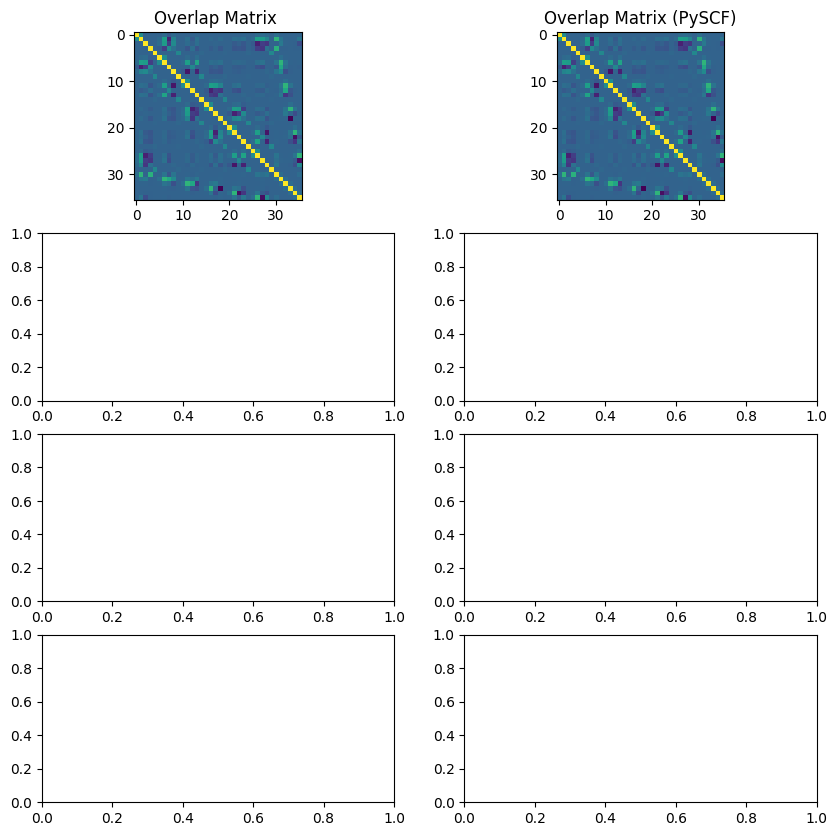

In [59]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 2, figsize=(10, 10))
axes[0, 0].set_title('Overlap Matrix ')
axes[0, 1].set_title('Overlap Matrix (PySCF)')  
axes[0, 0].imshow(S_my, cmap='viridis')
axes[0, 1].imshow(S_pyscf, cmap='viridis')
